# **Advanced Machine Learning**
# **D1.2 – Project Submission**

**C1 - DEPENDENCIAS + IMPORTS**

In [22]:
# Instalación segura de dependencias necesarias
import sys
import subprocess

# Lista de paquetes requeridos para el proyecto
packages = [
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'imbalanced-learn',
    'openpyxl',
    'xgboost',
    'optuna'
]

# Comprobamos si cada paquete está instalado, si no lo instalamos
for pkg in packages:
    try:
        if pkg == 'scikit-learn':
            __import__('sklearn')  # nombre interno distinto
        elif pkg == 'imbalanced-learn':
            __import__('imblearn')
        else:
            __import__(pkg)
        print(f"✓ {pkg} ya está instalado")
    except ImportError:
        print(f'Instalando {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f"✓ {pkg} instalado correctamente")

# Importación de librerías principales para análisis y modelado
try:
    import pandas as pd  # manipulación de datos
    import numpy as np   # operaciones numéricas
    import matplotlib.pyplot as plt  # visualización básica
    import seaborn as sns  # visualización avanzada

    # Preprocesamiento
    from sklearn.preprocessing import StandardScaler, LabelEncoder

    # División de datos
    from sklearn.model_selection import train_test_split

    # Modelo base
    from sklearn.ensemble import RandomForestClassifier

    # Pipeline (para integrar pasos de forma segura)
    from imblearn.pipeline import Pipeline

    # Métricas de evaluación
    from sklearn.metrics import classification_report, f1_score, confusion_matrix

    # Técnica de balanceo
    from imblearn.over_sampling import SMOTE

    print("\n✓ Todas las librerías importadas correctamente")

except Exception as e:
    print('Error en importaciones:', e)
    raise

✓ pandas ya está instalado
✓ numpy ya está instalado
✓ matplotlib ya está instalado
✓ seaborn ya está instalado
✓ scikit-learn ya está instalado
✓ imbalanced-learn ya está instalado
✓ openpyxl ya está instalado
✓ xgboost ya está instalado
Instalando optuna...
✓ optuna instalado correctamente

✓ Todas las librerías importadas correctamente


## **1. DATA PREPROCESSING**

**C2 — Preprocessing completo**

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder


# 1. Cargar el dataset
# Nota: Asegúrate de que el nombre del archivo coincida con la ruta en tu entorno
df = pd.read_excel("Dry_Bean_Dataset.xlsx")


# Visualizar si hay valores nulos inicialmente
print("Análisis de datos faltantes por columna:")
print(df.isnull().sum())


# 2. Separar características (X) y la variable objetivo (y)
X = df.drop(columns=['Class']) # features
y = df['Class'] # target


# 3. Codificación de la Variable Categórica (Target)
# Usamos LabelEncoder porque 'Class' es la variable objetivo multiclasificación
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# 4. Dividir el dataset en Entrenamiento y Prueba (CRÍTICO para evitar Data Leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


# 5. Estrategia de Imputación de Datos Faltantes (Missing Data)
# Aunque el dataset de Dry Beans no suele tener nulos, es una buena práctica incluir un imputador.
# Usamos la mediana porque es menos sensible a outliers en características geométricas.
imputer = SimpleImputer(strategy='median')


# IMPORTANTE: Hacemos fit_transform SOLAMENTE en el set de entrenamiento
X_train_imputed = imputer.fit_transform(X_train)

# Para el test, solo hacemos transform (usando las medianas calculadas en el train)
X_test_imputed = imputer.transform(X_test)


# 6. Estandarización / Normalización
# Usamos StandardScaler para que las variables tengan media 0 y desviación estándar 1.
# Esto es vital porque 'Area' está en decenas de miles y los 'ShapeFactors' son decimales muy pequeños.
scaler = StandardScaler()

# Nuevamente, fit_transform en Train, y solo transform en Test
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Convertir de nuevo a DataFrames (opcional, para mejor visualización o manejo posterior)
feature_names = X.columns
X_train_final = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_final = pd.DataFrame(X_test_scaled, columns=feature_names)



print("\nPreprocesamiento completado con éxito.")
print(f"Dimensiones de X_train_final: {X_train_final.shape}")
print(f"Dimensiones de X_test_final: {X_test_final.shape}")

Análisis de datos faltantes por columna:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

Preprocesamiento completado con éxito.
Dimensiones de X_train_final: (10888, 16)
Dimensiones de X_test_final: (2723, 16)


## **2. Imbalance Analysis and Mitigation**

**C3 - Imbalance**

In [3]:
# Importar las librerías de balanceo
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Visualizar el conteo original en el Train Set
print(f"Distribución original en y_train: {Counter(y_train)}")

# ---------------------------------------------------------
# TÉCNICA 1: Random Undersampling (Submuestreo)
# ---------------------------------------------------------
# Reduce todas las clases al tamaño de la clase minoritaria (BOMBAY: 418)
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_final, y_train)
print(f"Distribución tras UnderSampling: {Counter(y_train_rus)}")

# ---------------------------------------------------------
# TÉCNICA 2: Random Oversampling (Sobremuestreo)
# ---------------------------------------------------------
# Duplica los registros de las clases minoritarias hasta igualar a la mayoritaria (DERMASON: 2837)
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train_final, y_train)
print(f"Distribución tras OverSampling: {Counter(y_train_ros)}")

# ---------------------------------------------------------
# TÉCNICA 3: SMOTE (Synthetic Minority Over-sampling Technique)
# ---------------------------------------------------------
# Crea muestras SINTÉTICAS (no duplicadas) para las clases minoritarias
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_final, y_train)
print(f"Distribución tras SMOTE: {Counter(y_train_smote)}")

# Nota: El conjunto de prueba (X_test_final, y_test) se mantiene INTACTO para evaluar el modelo con datos reales.

Distribución original en y_train: Counter({np.int64(3): 2837, np.int64(6): 2109, np.int64(5): 1621, np.int64(4): 1542, np.int64(2): 1304, np.int64(0): 1057, np.int64(1): 418})
Distribución tras UnderSampling: Counter({np.int64(0): 418, np.int64(1): 418, np.int64(2): 418, np.int64(3): 418, np.int64(4): 418, np.int64(5): 418, np.int64(6): 418})
Distribución tras OverSampling: Counter({np.int64(5): 2837, np.int64(4): 2837, np.int64(2): 2837, np.int64(6): 2837, np.int64(3): 2837, np.int64(0): 2837, np.int64(1): 2837})
Distribución tras SMOTE: Counter({np.int64(5): 2837, np.int64(4): 2837, np.int64(2): 2837, np.int64(6): 2837, np.int64(3): 2837, np.int64(0): 2837, np.int64(1): 2837})


**C4 — Export**

In [25]:
# Unir X e y para guardarlos cómodamente en CSVs
# 1. Conjunto de Entrenamiento Balanceado (SMOTE) - EL PRINCIPAL
train_smote_df = pd.DataFrame(X_train_smote, columns=feature_names)
train_smote_df['Class'] = y_train_smote
train_smote_df.to_csv("train_data_SMOTE.csv", index=False)

# 2. Conjunto de Entrenamiento Original (Desbalanceado) - PARA COMPARAR EN EL PUNTO 5
train_original_df = X_train_final.copy()
train_original_df['Class'] = y_train
train_original_df.to_csv("train_data_IMBALANCED.csv", index=False)

# 3. Conjunto de Prueba (Test) - INTACTO, SOLO PARA EVALUACIÓN FINAL
test_df = X_test_final.copy()
test_df['Class'] = y_test
test_df.to_csv("test_data_FINAL.csv", index=False)

print("Archivos exportados con éxito para el resto del equipo.")

Archivos exportados con éxito para el resto del equipo.



**C5 — Info dataset**

In [4]:
# Confirmación final del estado del dataset
print("✓ Dataset completamente procesado y listo para modelado")

# Tamaño del dataset tras SMOTE
print(f"  - Datos de entrenamiento después de SMOTE: {X_train_smote.shape}")

# Clases presentes (ya balanceadas)
print(f"  - Clases balanceadas: {np.unique(y_train_smote)}")

✓ Dataset completamente procesado y listo para modelado
  - Datos de entrenamiento después de SMOTE: (19859, 16)
  - Clases balanceadas: [0 1 2 3 4 5 6]


**C6 — EDA**


--- 3. ANÁLISIS EXPLORATORIO DE DATOS ---


C:\Users\alvaro.franco\AppData\Local\Temp\ipykernel_24692\908587353.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='Set2')
C:\Users\alvaro.franco\AppData\Local\Temp\ipykernel_24692\908587353.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_smote, palette='Set2')


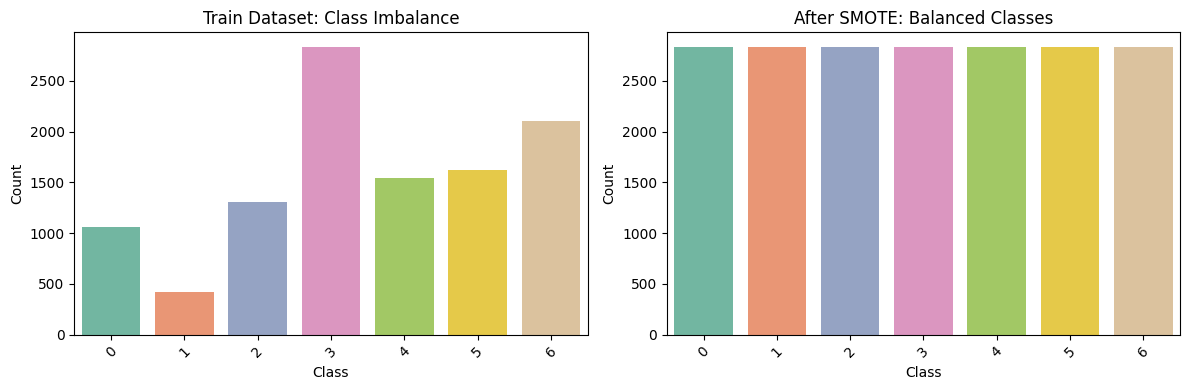


Distribuciones de características (primeras 4):


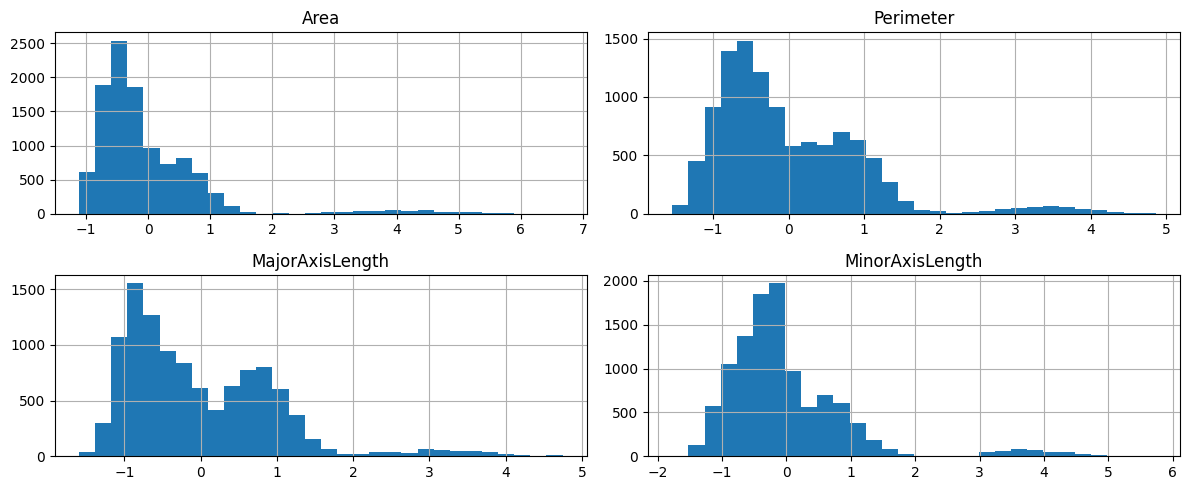


Matriz de correlación:


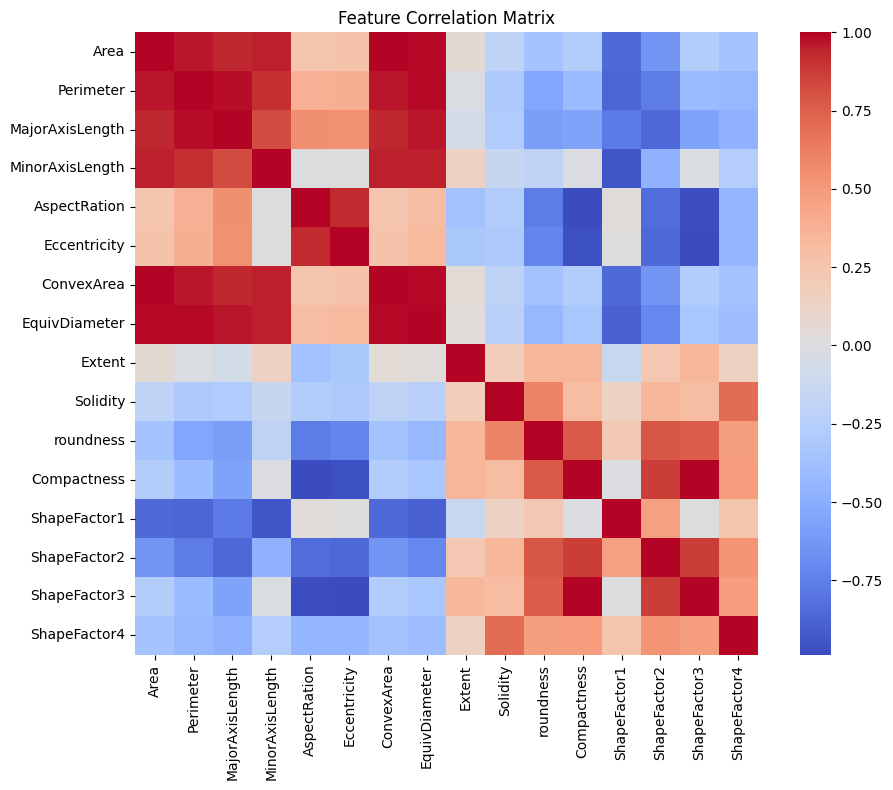


✓ Análisis exploratorio completado


In [6]:
# ---------------------------------------------------------
# Análisis exploratorio
# ---------------------------------------------------------
print("\n--- 3. ANÁLISIS EXPLORATORIO DE DATOS ---")

plt.figure(figsize=(12, 4))

# Distribución original en TRAIN (antes de balanceo)
plt.subplot(1, 2, 1)
sns.countplot(x=y_train, palette='Set2')
plt.title('Train Dataset: Class Imbalance')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Distribución tras aplicar SMOTE
plt.subplot(1, 2, 2)
sns.countplot(x=y_train_smote, palette='Set2')
plt.title('After SMOTE: Balanced Classes')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Distribución de características
# ---------------------------------------------------------
print("\nDistribuciones de características (primeras 4):")

X_train_final.iloc[:, :4].hist(figsize=(12, 5), bins=30)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Correlación entre variables
# ---------------------------------------------------------
print("\nMatriz de correlación:")

plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), cmap='coolwarm', square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print("\n✓ Análisis exploratorio completado")

## **3. Model Comparison and Hyperparameter Tuning**

**C8 - BASELINE**

In [13]:
# ---------------------------------------------------------
# BASELINE MODELS (SIN BALANCEO)
# ---------------------------------------------------------
# Objetivo:
# Establecer un punto de referencia antes de aplicar técnicas de imbalance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

print("\n--- BASELINE MODELS (NO IMBALANCE HANDLING) ---")

# ---------------------------------------------------------
# Logistic Regression (modelo lineal simple)
# ---------------------------------------------------------
lr = LogisticRegression(max_iter=1000, random_state=42)

# Entrenamos SOLO con datos originales (sin SMOTE ni class_weight)
lr.fit(X_train_scaled, y_train)

# Predicción sobre test (intacto)
y_pred_lr = lr.predict(X_test_scaled)

print("\n=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print("Macro F1:", f1_score(y_test, y_pred_lr, average="macro"))

# ---------------------------------------------------------
# Decision Tree (modelo base de ensembles)
# ---------------------------------------------------------
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

print("\n=== Decision Tree ===")
print(classification_report(y_test, y_pred_dt))
print("Macro F1:", f1_score(y_test, y_pred_dt, average="macro"))


--- BASELINE MODELS (NO IMBALANCE HANDLING) ---

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.95      0.89      0.92       265
           1       1.00      1.00      1.00       104
           2       0.93      0.94      0.94       326
           3       0.92      0.91      0.92       709
           4       0.96      0.95      0.96       386
           5       0.93      0.95      0.94       406
           6       0.85      0.88      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723

Macro F1: 0.9335383155807854

=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.88      0.91      0.89       265
           1       1.00      1.00      1.00       104
           2       0.92      0.91      0.92       326
           3       0.88      0.90      0.89       709
  

### **MODEL 1. RANDOM FOREST**

**C9 — Modelo A**

In [7]:
# ---------------------------------------------------------
# Modelo A: RandomForest con class_weight
# ---------------------------------------------------------
print("\n--- MODELO A: RandomForest (class_weight) ---")

# Ajustamos pesos automáticamente para clases desbalanceadas
rf_a = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# Entrenamiento
rf_a.fit(X_train_scaled, y_train)

# Predicción
y_pred_a = rf_a.predict(X_test_scaled)

# Evaluación
print(classification_report(y_test, y_pred_a))
print("Macro F1:", f1_score(y_test, y_pred_a, average="macro"))

# Matriz de confusión
cm_a = confusion_matrix(y_test, y_pred_a)
print(cm_a)

print("\n✓ Modelo A completado")


--- MODELO A: RandomForest (class_weight) ---
              precision    recall  f1-score   support

           0       0.94      0.89      0.91       265
           1       1.00      1.00      1.00       104
           2       0.94      0.94      0.94       326
           3       0.91      0.92      0.92       709
           4       0.97      0.95      0.96       386
           5       0.94      0.96      0.95       406
           6       0.86      0.85      0.85       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723

Macro F1: 0.9326187597475176
[[236   0  17   0   1   2   9]
 [  0 104   0   0   0   0   0]
 [ 10   0 305   0   5   2   4]
 [  0   0   0 655   0  10  44]
 [  1   0   4   4 368   0   9]
 [  1   0   0   6   0 389  10]
 [  4   0   0  55   7  11 450]]

✓ Modelo A completado


In [ ]:
# ---------------------------------------------------------
# COMPARACIÓN: BASELINE vs RANDOM FOREST
# ---------------------------------------------------------
# Objetivo:
# Comparar modelos simples vs modelo ensemble

print("\n--- COMPARACIÓN DE MODELOS ---")

# Calcular métricas principales
f1_lr = f1_score(y_test, y_pred_lr, average="macro")
f1_dt = f1_score(y_test, y_pred_dt, average="macro")
f1_rf = f1_score(y_test, y_pred_a, average="macro")  # RandomForest (Modelo A)

# Mostrar resultados
print("\nMacro F1 Scores:")
print(f"Logistic Regression: {f1_lr:.4f}")
print(f"Decision Tree:       {f1_dt:.4f}")
print(f"Random Forest:       {f1_rf:.4f}")

# Mejor modelo
best_model = max(
    [("Logistic Regression", f1_lr),
    ("Decision Tree", f1_dt),
    ("Random Forest", f1_rf)],
    key=lambda x: x[1]
)

print(f"\nMejor modelo hasta ahora: {best_model[0]} ({best_model[1]:.4f})")


--- COMPARACIÓN DE MODELOS ---

Macro F1 Scores:
Logistic Regression: 0.9335
Decision Tree:       0.9081
Random Forest:       0.9326

Mejor modelo hasta ahora: Logistic Regression (0.9335)


**INSIGHT**: “Interestingly, Logistic Regression slightly outperformed Random Forest, suggesting that the dataset is well-structured and linearly separable to a large extent.”

**C10 — Modelo B + comparación**

In [15]:
# ---------------------------------------------------------
# Modelo B: Pipeline con SMOTE
# ---------------------------------------------------------
print("\n--- MODELO B: SMOTE + RandomForest ---")

# SMOTE dentro del pipeline → evita data leakage
smote_pipe = SMOTE(random_state=42)

rf_b = RandomForestClassifier( #To isolate the effect of SMOTE, class_weight was removed in this configuration
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

pipe_b = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", smote_pipe),
    ("rf", rf_b)
])

# Entrenamiento
pipe_b.fit(X_train, y_train)

# Predicción
y_pred_b = pipe_b.predict(X_test)

# Evaluación
print(classification_report(y_test, y_pred_b))
print("Macro F1:", f1_score(y_test, y_pred_b, average="macro"))

# ---------------------------------------------------------
# Comparación final
# ---------------------------------------------------------
f1_a = f1_score(y_test, y_pred_a, average="macro")
f1_b = f1_score(y_test, y_pred_b, average="macro")

print(f"\nMétodo A: {f1_a:.4f}")
print(f"Método B: {f1_b:.4f}")
print(f"Mejor método: {'A (class_weight)' if f1_a > f1_b else 'B (SMOTE)' if f1_b > f1_a else 'Empate'}")


--- MODELO B: SMOTE + RandomForest ---
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       265
           1       1.00      1.00      1.00       104
           2       0.94      0.94      0.94       326
           3       0.92      0.91      0.91       709
           4       0.96      0.95      0.96       386
           5       0.94      0.96      0.95       406
           6       0.86      0.86      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723

Macro F1: 0.9325596766874037

Método A: 0.9326
Método B: 0.9326
Mejor método: A (class_weight)


**INSIGHT:** The application of SMOTE did not lead to any significant improvement in model performance. 
This is likely due to the fact that the dataset, although imbalanced, is highly separable based on its features. 
As a result, the model is already able to correctly classify minority classes without the need for synthetic data generation.

**C10 - ENSEMBLE METHODS**

In [16]:
# ---------------------------------------------------------
# ENSEMBLE MODELS (SIN TUNING)
# ---------------------------------------------------------
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier

print("\n--- ENSEMBLE MODELS (BASE) ---")

# Diccionario de modelos
models = {
    "Random Forest": rf_a,  # ya entrenado
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():
    print(f"\nEntrenando {name}...")

    if name != "Random Forest":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = y_pred_a  # ya lo tienes

    f1 = f1_score(y_test, y_pred, average="macro")
    results[name] = f1

    print(f"{name} - Macro F1: {f1:.4f}")

# Mostrar resumen
print("\n--- RESUMEN ---")
for name, score in results.items():
    print(f"{name}: {score:.4f}")


--- ENSEMBLE MODELS (BASE) ---

Entrenando Random Forest...
Random Forest - Macro F1: 0.9326

Entrenando Gradient Boosting...
Gradient Boosting - Macro F1: 0.9343

Entrenando AdaBoost...
AdaBoost - Macro F1: 0.6780

Entrenando Extra Trees...
Extra Trees - Macro F1: 0.9283

--- RESUMEN ---
Random Forest: 0.9326
Gradient Boosting: 0.9343
AdaBoost: 0.6780
Extra Trees: 0.9283


XGBoost is an advanced boosting algorithm that extends traditional Gradient Boosting by incorporating regularization techniques and more efficient optimization strategies. 

Due to these improvements, it often achieves competitive or superior performance, making it a relevant model to include in our comparison.

In [19]:
# ---------------------------------------------------------
# XGBoost Model
# ---------------------------------------------------------
# Advanced boosting method with regularization and efficient optimization

from xgboost import XGBClassifier

print("\n--- XGBoost ---")

xgb = XGBClassifier(
    n_estimators=200,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss',
    n_jobs=-1
)

# Entrenamiento
xgb.fit(X_train_scaled, y_train)

# Predicción
y_pred_xgb = xgb.predict(X_test_scaled)

# Evaluación
f1_xgb = f1_score(y_test, y_pred_xgb, average="macro")

print("Macro F1:", f1_xgb)


--- XGBoost ---


c:\Users\alvaro.franco\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:07:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Macro F1: 0.9347338603971646


### Model Ranking and Selection

After evaluating several baseline and ensemble models, we rank them based on their Macro F1 score, which is an appropriate metric for imbalanced classification problems.

The goal of this step is to identify the most promising models for further optimization using hyperparameter tuning techniques.

Rather than tuning all models, we focus only on the top-performing ones, as this allows us to efficiently allocate computational resources and avoid unnecessary complexity.

The selected models will be optimized using Optuna in the next section.

In [21]:
# ---------------------------------------------------------
# MODEL RANKING AND SELECTION
# ---------------------------------------------------------
# Objective:
# Rank all evaluated models and select the most promising ones
# for further hyperparameter tuning (Optuna)

print("\n--- MODEL RANKING ---")

# Guardar resultados (asegúrate de que todas estas variables existen)
model_results = {
    "Logistic Regression": f1_lr,
    "Decision Tree": f1_dt,
    "Random Forest": f1_a,
    "Gradient Boosting": results["Gradient Boosting"],
    "Extra Trees": results["Extra Trees"],
    "AdaBoost": results["AdaBoost"],
    "XGBoost": f1_xgb
}

# Ordenar modelos por rendimiento
sorted_models = sorted(model_results.items(), key=lambda x: x[1], reverse=True)

# Mostrar ranking
for i, (name, score) in enumerate(sorted_models, 1):
    print(f"{i}. {name}: {score:.4f}")

# Selección de los mejores modelos
top_models = sorted_models[:2]

print("\n--- SELECTED MODELS FOR TUNING ---")
for name, score in top_models:
    print(f"{name}: {score:.4f}")
    
print("\nNOTE:")
print("Differences between top models are small, suggesting that the dataset is relatively easy to classify.")


--- MODEL RANKING ---
1. XGBoost: 0.9347
2. Gradient Boosting: 0.9343
3. Logistic Regression: 0.9335
4. Random Forest: 0.9326
5. Extra Trees: 0.9283
6. Decision Tree: 0.9081
7. AdaBoost: 0.6780

--- SELECTED MODELS FOR TUNING ---
XGBoost: 0.9347
Gradient Boosting: 0.9343

NOTE:
Differences between top models are small, suggesting that the dataset is relatively easy to classify.


**INSIGHT:** Only the top-performing models (XGBoost and Gradient Boosting) were selected for hyperparameter tuning. 

This decision allows us to focus computational resources on the most promising approaches, while avoiding unnecessary optimization of models that already showed inferior performance.

### Hyperparameter Tuning with Optuna (XGBoost)

In this section, we apply hyperparameter optimization using Optuna to improve the performance of the XGBoost model.

Optuna is an efficient optimization framework that explores the hyperparameter space using intelligent sampling strategies and prunes unpromising trials to reduce computational cost.

We use cross-validation to ensure robust performance estimation and optimize the Macro F1 score, which is appropriate for imbalanced classification problems.

In [ ]:
# ---------------------------------------------------------
# OPTUNA TUNING - XGBOOST
# ---------------------------------------------------------
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from xgboost import XGBClassifier

print("\n--- OPTUNA: XGBOOST ---")

# Cross-validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def objective(trial):
    
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 400),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "random_state": 42,
        "n_jobs": -1,
        "eval_metric": "mlogloss"
    }

    scores = []

    for train_idx, val_idx in cv.split(X_train_scaled, y_train):
        X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        model = XGBClassifier(**params)
        model.fit(X_tr, y_tr)

        y_pred = model.predict(X_val)
        score = f1_score(y_val, y_pred, average="macro")
        scores.append(score)

    return np.mean(scores)

# Pruner (early stopping de trials malos)
pruner = optuna.pruners.MedianPruner()

study = optuna.create_study(direction="maximize", pruner=pruner)

study.optimize(objective, n_trials=25)

print("\nBest parameters:")
print(study.best_params)

print("\nBest CV Macro F1:")
print(study.best_value)